In [1]:
%matplotlib inline

import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import jax.nn as nn
import seaborn as snb

from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

# Assignment 2

## Part 1 - Gaussian processes and covariance functions

$$\begin{align}
k_1(x,x') &= 2\exp\left({-\frac{(x-x')^2}{2\cdot 0.3^2}}\right)\\
k_2(x,x') &= \exp\left({-\frac{(x-x')^2}{2\cdot 0.1^2}}\right)\\
k_3(x,x') &= 4+2xx'\\
k_4(x,x') &= \exp\left(-2\sin(3\pi \cdot|x-x'|)^2\right)\\
k_5(x,x') &= \exp\left(-2\sin(3\pi \cdot|x-x'|)^2\right)+4xx'\\
k_6(x,x') &= \frac{1}{5}+\min(x,x')
\end{align}$$

### Task 1.1
Determening the analytical marginal prior and mean of the Gaussian proccesses.

For a Gaussian process $f(\mathbf{x}) \sim \mathcal{GP}\left(m(\mathbf{x}) \, , \, k\left(\mathbf{x}, \mathbf{x}'\right)\right)$, we have that $\mathbb{E}[\mathbf{f}]=m(\mathbf{x})$. Since all the Gaussian processes follow $f_i(x) \sim \mathcal{GP}\left(0 \, , \, k_i\left(x, x'\right)\right)$ the analytical prior mean is 0 for all $f_i(x)$.
The variance is given by 
$$
\mathbb{V}[\mathbf{f}]=\mathbb{V}[\mathbf{Lz}+\mathbf{m}]= \mathbf{L}\mathbb{V}[\mathbf{z}]\mathbf{L}^T=\mathbf{L}\mathbf{I}\mathbf{L}^T=\mathbf{LL}^T=\mathbf{K}
$$
so for each $f_i(x)$ the variance is $k_i(x,x)$.

This gives
$$
\begin{align*}
k_1(x,x)=2\exp(-\frac{0^2}{2\cdot0.3^2})=2\exp(0)=2\\

etc.
\end{align*}
$$

### Task 1.2
Determening if convariance functions are stationary.

A covariance function is stationary, if it only depends on the difference between two points, $\tau = \mathbf{x}_n - \mathbf{x}_m$. From this we kan see that $k_1,k_2$, and $k_4$ are all stationary. One might be inclined to label $k_5$ as stationary as well, since it also depends on the difference in two points. However, it also contains $xx'$, which makes it non-stationary.

### Task 1.3
Matching plots and kernels

In order to match the plots in Figure 1 from the assignment description, we can use the code from Week 5 used to construct and plot the kernels, to make our own plot, and see which are similar to the ones in Figrue 1.

In [2]:
def generate_samples(key, m, K, num_samples, jitter=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter * jnp.identity(N))

    f_samples = jnp.dot(L,zs) + m[:, None]
    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples

In [3]:
# in the code below tau represents the distance between to input points, i.e. tau = ||x_n - x_m||.
def k1(X1,X2,params):
    dist = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    return 2*jnp.exp(-dist**2/(2*0.3**2))

def k2(X1,X2,params):
    dist = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    return jnp.exp(-dist**2/(2*0.1**2))

def k3(X1,X2,params):
    return 4 + 2*jnp.dot(X1, X2.T)

def k4(X1,X2,params):
    dist = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    return jnp.exp(-2*jnp.sin(3*jnp.pi*jnp.abs(dist))**2)

def k5(X1,X2,params):
    dist = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    return jnp.exp(-2*jnp.sin(3*jnp.pi*jnp.abs(dist))**2) + 4*jnp.dot(X1, X2.T)

def k6(X1,X2,params):
    return 1/5 + jnp.minimum(X1, X2.T)

In [4]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, params=[0], jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################

        K = self.kernel_fun(X1,X2,params)
        if len(X1)==len(X2) and jnp.allclose(X1,X2):
            K = K + jitter*jnp.identity(len(X1))
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

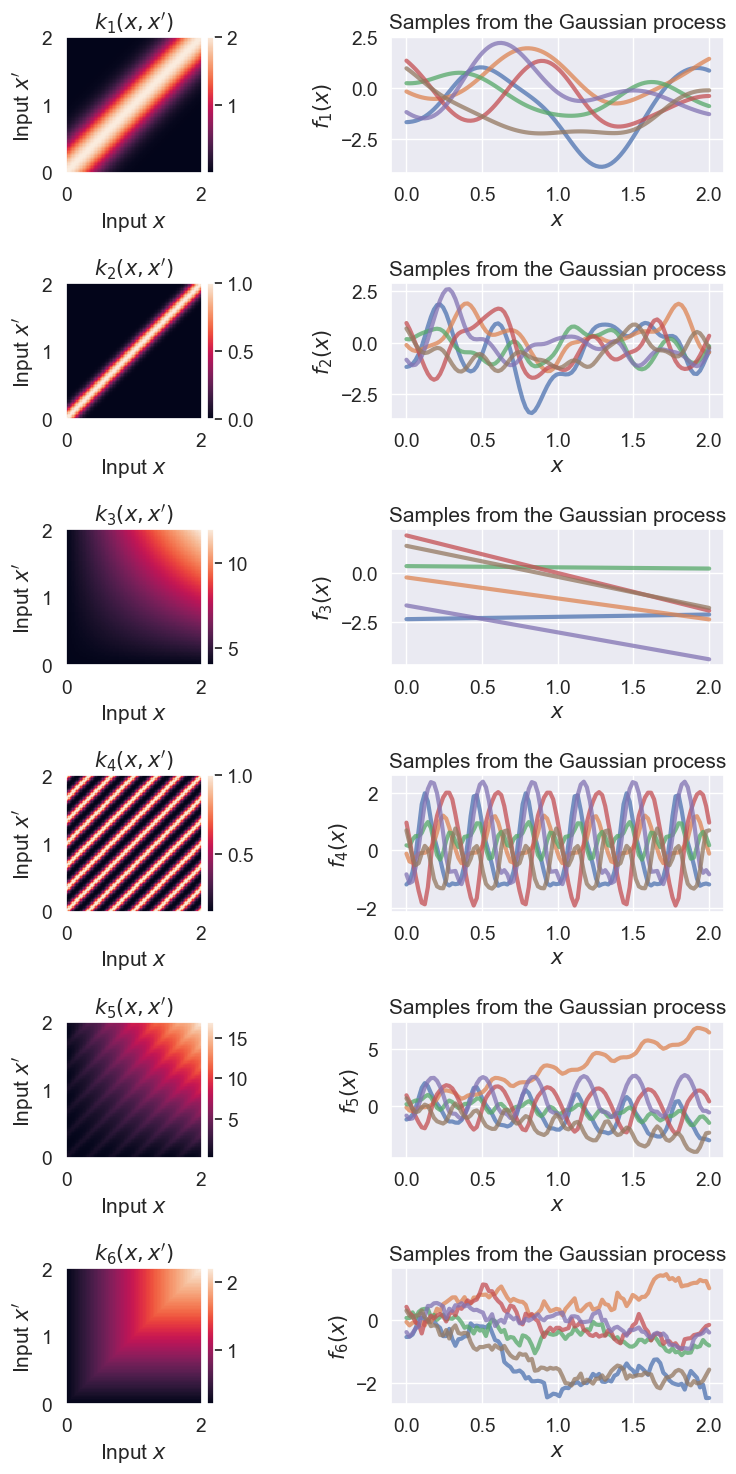

In [5]:
ks = [k1,k2,k3,k4,k5,k6]
fig, ax = plt.subplots(6,2, figsize=(8,15))

# number of samples to be plotted
num_samples = 6

# specify random seed
key = random.PRNGKey(1)

X = jnp.linspace(0,2, 100)[:, None]

for i, k in enumerate(ks):
    # instantiate kernel object and construct kernel
    kernel = StationaryIsotropicKernel(k)
    K = kernel.construct_kernel(X, X)

    im = ax[i][0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
    ax[i][0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"$k_{i+1}(x, x')$")
    ax[i][0].grid(False)
    ax[i][0].set_aspect('equal')
    add_colorbar(im, fig, ax[i][0])

    m = jnp.zeros(len(X))
    f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
    ax[i][1].plot(X, f_samples, alpha=0.75, linewidth=3);
    ax[i][1].grid(True)
    ax[i][1].set(xlabel='$x$', ylabel=f'$f_{i+1}(x)$', title='Samples from the Gaussian process')

plt.tight_layout()
plt.show()

From these plots, we can see that $k_1(x,x')$ matches plot (d), which makes sense, as it is a squared exponential kernel with a higher $\kappa$, which means it has a higher variance, which can be seen by how it affects the kernel (left), making it wider along the diagonal. It also as a higher lengthscale, $\ell$, than $k_2$, which means the function is smoother. $k_2(x,x')$ matches plot (a), as it is also a squared exponential function, with a lower $\kappa$, which makes the correlation along the diagonal of the kernel narrower. It also as a lower $\ell$, which means it has a shorter correlation length, and therefore is less smooth. $k_3(x,x')$ is a linear kernel and matches plot (f). $k_4(x,x')$ matches plot (e), where you can see the periods of sine. $k_5(x,x')$ also has sine in it's function, however, it also has a linear part, which can be seen in plot (c). $k_6(x,x')$ is a min kernel and matches plot (b).

$$
\begin{align}
k_7(x,x')=\kappa_0^2 + \kappa_1^2xx'+\kappa_2^2\exp\left(-\frac{\|x-x'\|^2_2}{2\ell^2}\right) \tag{7}
\end{align}
$$

### Task 1.4

$k_7(x,x')$ can be seen in the plot bellow, with $x\in[-6,6]$ for $(\kappa_0,\kappa_1,\kappa_2,\ell)=(5,2,0,\frac{1}{2})$, $(\kappa_0,\kappa_1,\kappa_2,\ell)=(5,0,1,\frac{1}{2})$, and $(\kappa_0,\kappa_1,\kappa_2,\ell)=(5,2,1,\frac{1}{2})$

In [6]:
def k7(X1,X2,params):
    kap0,kap1,kap2,l = params
    dist = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
    return kap0**2 + kap1**2*jnp.dot(X1, X2.T) + kap2**2*jnp.exp(-(dist)**2/(2*l**2))

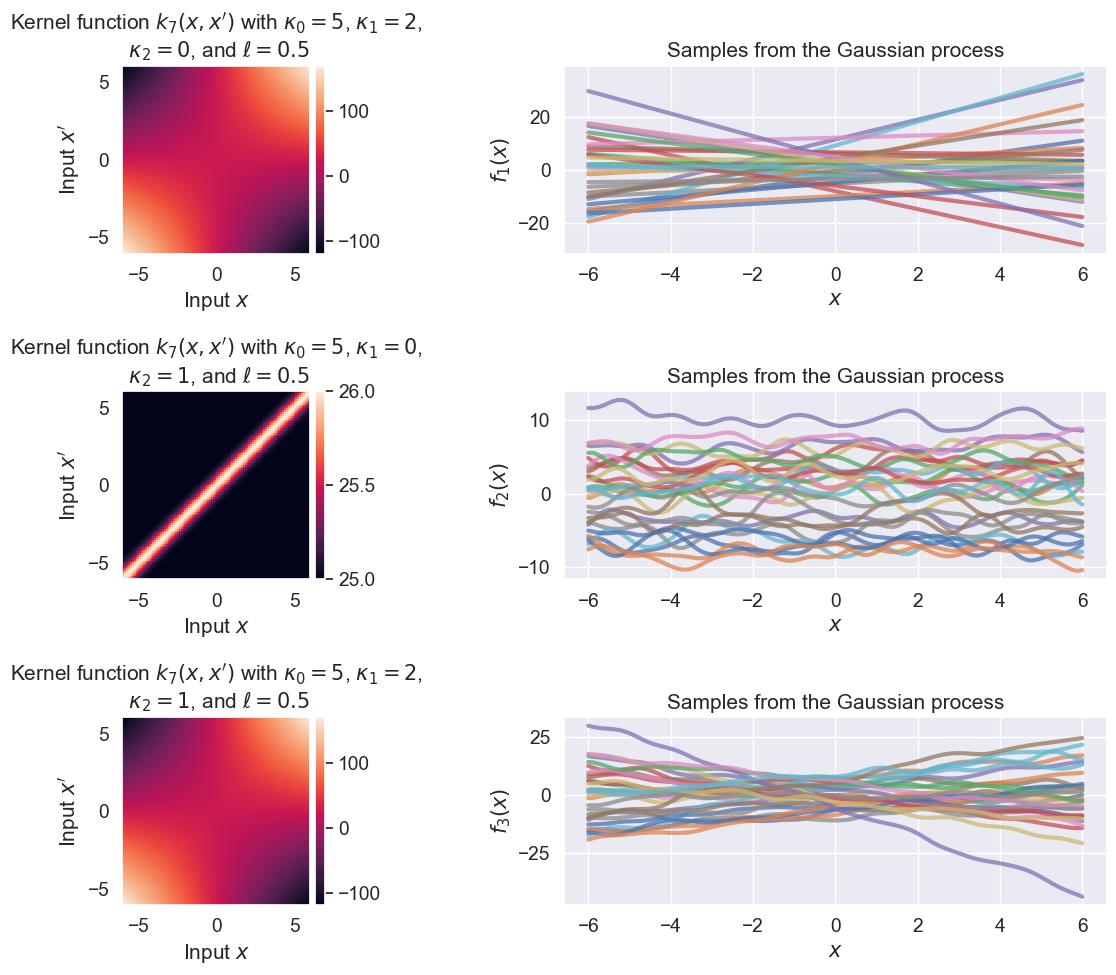

In [7]:
params = [[5,2,0,0.5], [5,0,1,0.5],[5,2,1,0.5]]

fig, ax = plt.subplots(3,2, figsize=(12,10))

# number of samples to be plotted
num_samples = 30

# specify random seed
key = random.PRNGKey(1)

X = jnp.linspace(-6,6, 100)[:, None]

for i, param in enumerate(params):
    # instantiate kernel object and construct kernel
    kernel = StationaryIsotropicKernel(k7)
    K = kernel.construct_kernel(X, X,param)

    im = ax[i][0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
    ax[i][0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k_7(x, x')$ with $\kappa_0={param[0]}$, $\kappa_1={param[1]}$,\n $\kappa_2={param[2]}$, and $\ell={param[3]}$")
    ax[i][0].grid(False)
    ax[i][0].set_aspect('equal')
    add_colorbar(im, fig, ax[i][0])

    m = jnp.zeros(len(X))
    f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
    ax[i][1].plot(X, f_samples, alpha=0.75, linewidth=3);
    ax[i][1].grid(True)
    ax[i][1].set(xlabel='$x$', ylabel=f'$f_{i+1}(x)$', title='Samples from the Gaussian process')

plt.tight_layout()
plt.show()

## Part 2 - Laplace approximation for a simple neural network

For a small regression dataset we have $N=10$ observations $\mathcal{D}={(x_n,y_n)}^M_{n=1}$, where
$$\begin{equation}
\mathbf{x}=[9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783]\tag{8}
\end{equation}$$
$$\begin{equation}
\mathbf{y}=[3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828,−0.331]\tag{9}
\end{equation}$$

such that the $n$'th element of $\mathbf{x}$ is $x_n\in \mathbb{R}$ and the $n$'th element of $\mathbf{y}$ is $y_n\in \mathbb{R}$. We also have a two parameter neural network 

$$\begin{equation}
f(x)=w_1\sigma(x+w_0)\tag{10}
\end{equation}$$

where $\mathbf{w}=[w_0,w_2] \in \mathbb{R}^2$ are the parameters of the network and $\sigma: \mathbb{R} \rightarrow(0,1)$ is the logistic sigmoid function. From this we can construct a non-linear porbabilistic model for regression by using the network $f(x)$ as the mean function fo a Gaussian likelihood:
$$\begin{equation}
p(y_n|x_n,\mathbf{w})=\mathcal{N}(y_n|f(x),\beta^{-1})=\mathcal{N}(y_n|w_1\sigma(x+w_0), \beta^{-1}),\tag{11}
\end{equation}$$
where $\beta^{-1}$ is the noise variance. Furthermore we impose i.i.d. Gaussian prior distributions on both parameters:
$$\begin{equation}
w_0\sim\mathcal{N}(0,\tau^2)\tag{12}
\end{equation}$$
$$\begin{equation}
w_1\sim\mathcal{N}(0,\tau^2),\tag{13}
\end{equation}$$

where $\tau^2>0$ is the variance of the prior.

We assume that $\tau=2$ and $\beta=4$

### Task 2.1

In the plot below 100 samples from the prior $p(w)$, their corresponding functions $f(x)$ for $x \in [0,10]$ on top of a scatterplot of the data

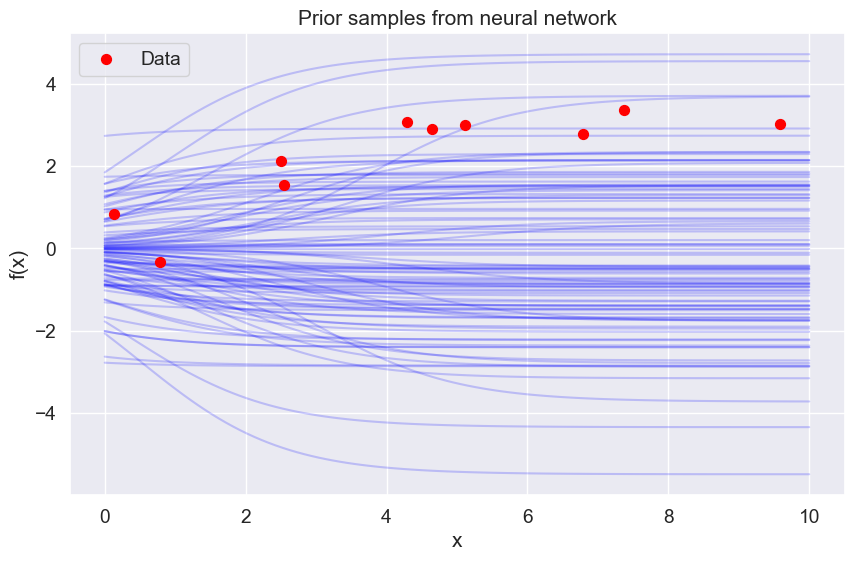

In [8]:
tau = 2
beta = 4
S = 100
key = random.PRNGKey(42)

x = jnp.array([9.589, 7.375, 4.647, 2.501, 2.538, 6.783, 4.294, 5.111, 0.130, 0.783])
y = jnp.array([3.032, 3.349, 2.906, 2.126, 1.538, 2.787, 3.078, 2.993, 0.828, -0.331])

w_samples = random.normal(key, shape=(S, 2)) * tau  
def f(x, w):
    w0, w1 = w
    return w1 * nn.sigmoid(x + w0)

x_plot = jnp.linspace(0, 10, 100)
f_samples = jnp.array([f(x_plot, w_samples[i]) for i in range(S)])

plt.figure(figsize=(10, 6))
plt.plot(x_plot, f_samples.T, alpha=0.2, color='blue')  
plt.scatter(x, y, color='red', s=50, label='Data', zorder=5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Prior samples from neural network')
plt.legend()
plt.grid(True)
plt.show()

### Task 2.2

The joint density for $(\mathbf{y},\mathbf{w})$ is
$$
\begin{equation}
p(\mathbf{y},\mathbf{w})=p(\mathbf{w})\Pi_{n=1}^Np(y_n|x_n,\mathbf{w})=\mathcal{N}(w_0|0,\tau^2)\mathcal{N}(w_1|0,\tau^2)\Pi_{n=1}^N\mathcal{N}(y_n|w_1\sigma(x_n+w_0),\beta^{-1}) \tag{14}
\end{equation}
$$


Even though the prior is Gaussian, the likelihood function involves a non-linear transformation through the sigmoid function. Because of this non-linearity the conjugacy is broken, which means it isn't possible to compute the posterior distribution in closed form. It is therefore not possible to calculate it on closed form, and it is therefore necessary to estimate it using Laplace.

### Task 2.3

In the cell below is a function for the log joint density function

In [9]:
def log_joint(y,x,w0,w1,tau,beta):
    prior_w0 = -1/2*jnp.log(2*jnp.pi*tau**2)-1/(2*tau**2)*w0**2
    prior_w1 = -1/2*jnp.log(2*jnp.pi*tau**2)-1/(2*tau**2)*w1**2

    f_pred = w1*nn.sigmoid(x+w0)
    noise_var = 1/beta
    log_like = jnp.sum(-1/2*jnp.log(2*jnp.pi*noise_var)-1/(2*noise_var)*(y-f_pred)**2)

    return prior_w0 + prior_w1 + log_like

In [10]:
w0 = 0
w1 = 0
tau = 2
beta = 4

log_joint(y,x,w0,w1,tau,beta)

Array(-130.94934095, dtype=float64)

The log joint density function for $w_0=w_1=0$ is approximately $-130.95$

### Task 2.4

The gradient of the logarithm of the joint density wrt. $\mathbf{w}$ is the first order derivative of the of the function, and the Hessian is the second order derivative. From this we get that the gradient is

$$
\begin{align*}
\nabla _{\mathbf{w}} \log p(\mathbf{y,\mathbf{w}})=\begin{bmatrix}
\frac{\partial}{\partial w_0} \log p(\mathbf{y,\mathbf{w}})\\
\frac{\partial}{\partial w_1} \log p(\mathbf{y,\mathbf{w}})
\end{bmatrix}= \begin{bmatrix}
-\frac{w_0}{\tau^2} + \frac{1}{\beta^{-1}}\sum_{n=1}^N(y_n - w_1\sigma(x_n+w_0)) w_1\sigma(x_n+w_0)(1-\sigma(x_n+w_0))\\
-\frac{w_1}{\tau^2} - \frac{1}{\beta^{-1}}\sum_{n=1}^N(y_n-w_1\sigma(x_n+w_0))\sigma(x_n+w_0)
\end{bmatrix}
\end{align*}
$$

$$\nabla_{\mathbf{w}} \log p(\mathbf{y},\mathbf{w}) = \begin{bmatrix}
-\frac{w_0}{\tau^2} + \frac{1}{\beta^{-1}}\sum_{n=1}^N (y_n - w_1\sigma(x_n+w_0)) w_1\sigma(x_n+w_0)(1-\sigma(x_n+w_0))\\
-\frac{w_1}{\tau^2} - \frac{1}{\beta^{-1}}\sum_{n=1}^N (y_n - w_1\sigma(x_n+w_0))\sigma(x_n+w_0)
\end{bmatrix}$$

and the Hessian is

### Task 2.5
